# PRODUCTION: DTU ORBIT Meta Data

## Cleaning the Metadata from DTU ORBIT

### Loading the data

In [ ]:
import pandas as pd
import IPython

df_orbit = pd.read_csv('../Data/Orbit_meta/dtu_orbit_persons_raw.csv')
pd.set_option("display.max_colwidth", None)  # Show full text in cells

# making everything in the dataset lowercase
df_orbit = df_orbit.map(lambda x: x.lower() if isinstance(x, str) else x)

# Professor, National Institute of Aquatic Resources
display(df_orbit.head(2))
print("Number of rows in raw dataset: ", len(df_orbit))

,url,name,affiliations,email,orcid,website,address,profile_text,keywords,sdgs
0,https://orbit.dtu.dk/en/persons/a-s-m-lutfor-rahman-rabbi/,a s m lutfor rahman rabbi,"teaching assistant, department of technology, management and economics",asmlur@dtu.dk,NaN,http://www.man.dtu.dk,denmark,NaN,NaN,NaN
1,https://orbit.dtu.dk/en/persons/aage-thaarup/,aage thaarup,"fisheries technician, national institute of aquatic resources; section for monitoring and data",att@aqua.dtu.dk,NaN,http://www.aqua.dtu.dk,"willemoesvej 2 , hovedbygning, 068 9850 hirtshals denmark",NaN,NaN,NaN


Number of rows in raw dataset:  5734


### Splitting affiliations into: ``professional_title`` & ``dtu_department``

In [2]:
# Split affiliations into:
# 1) professional_title (before first comma)
# 2) dtu_department (after first comma)
parts = df_orbit["affiliations"].astype("string").str.split(",", n=1, expand=True)

df_orbit["professional_title"] = parts[0].str.strip()
df_orbit["dtu_department"] = parts[1].str.strip()

# If no comma existed, keep department as missing value (already NaN/<NA>)
df_orbit["dtu_department"] = df_orbit["dtu_department"].fillna(pd.NA)

# Quick check
display(df_orbit[["affiliations", "professional_title", "dtu_department"]].head(10))
print("Rows with missing title:", df_orbit["professional_title"].isna().sum())
print("Rows with missing department:", df_orbit["dtu_department"].isna().sum())

,affiliations,professional_title,dtu_department
0,"teaching assistant, department of technology, management and economics",teaching assistant,"department of technology, management and economics"
1,"fisheries technician, national institute of aquatic resources; section for monitoring and data",fisheries technician,national institute of aquatic resources; section for monitoring and data
2,"postdoc, department of civil and mechanical engineering; manufacturing engineering",postdoc,department of civil and mechanical engineering; manufacturing engineering
3,"postdoc, national food institute; research group for food allergy",postdoc,national food institute; research group for food allergy
4,"metabolomics core manager, department of biotechnology and biomedicine; section for microbial and chemical ecology; dtu metabolomics core; natural product discovery; center for microbial secondary metabolites",metabolomics core manager,department of biotechnology and biomedicine; section for microbial and chemical ecology; dtu metabolomics core; natural product discovery; center for microbial secondary metabolites
5,"student assistant, department of electrical and photonics engineering",student assistant,department of electrical and photonics engineering
6,"professor, department of applied mathematics and computer science; visual computing",professor,department of applied mathematics and computer science; visual computing
7,"postdoc, department of applied mathematics and computer science; cognitive systems",postdoc,department of applied mathematics and computer science; cognitive systems
8,"phd student, department of energy conversion and storage; structural analysis and modelling",phd student,department of energy conversion and storage; structural analysis and modelling
9,"phd student, department of technology, management and economics",phd student,"department of technology, management and economics"


Rows with missing title: 4
Rows with missing department: 11


### Keeping only titles allowed to supervise

In [3]:
# Filter: who can be main supervisor (hovedvejleder) per DTU rules
# Job categories: adjunkt, lektor, docent, ingeniørdocent, professor, forsker, seniorforsker, seniorrådgiver
SUPERVISOR_TITLES = {
    'adjunkt', 'lektor', 'docent', 'ingeniørdocent', 'professor', 'forsker', 'seniorforsker', 'seniorrådgiver',
    'assistant professor', 'associate professor', 'professor', 'researcher', 'senior researcher', 'senior adviser', 'senior advisor'
}

# Normalize title column before filtering (safe)
df_orbit["professional_title"] = df_orbit["professional_title"].astype("string").str.strip()

before = len(df_orbit)
df_orbit_cut = df_orbit[df_orbit["professional_title"].isin(SUPERVISOR_TITLES)].copy()
after = len(df_orbit_cut)

print(f"Rows removed: {before - after}")
print(f"Rows remaining: {after}")


Rows removed: 4846
Rows remaining: 888


In [4]:
display(df_orbit_cut[["affiliations", "professional_title", "dtu_department"]])

,affiliations,professional_title,dtu_department
6,"professor, department of applied mathematics and computer science; visual computing",professor,department of applied mathematics and computer science; visual computing
10,"researcher, department of physics; 2d materials engineering and physics",researcher,department of physics; 2d materials engineering and physics
15,"researcher, national food institute; research group for food allergy",researcher,national food institute; research group for food allergy
16,"associate professor, department of health technology; hearing systems section; computational auditory modeling",associate professor,department of health technology; hearing systems section; computational auditory modeling
19,"associate professor, national centre for nano fabrication and characterization; nanofabrication; polymer microsystems",associate professor,national centre for nano fabrication and characterization; nanofabrication; polymer microsystems
...,...,...,...
5686,"senior researcher, department of civil and mechanical engineering; manufacturing engineering",senior researcher,department of civil and mechanical engineering; manufacturing engineering
5687,"associate professor, department of environmental and resource engineering; geotechnics & geology",associate professor,department of environmental and resource engineering; geotechnics & geology
5691,"senior researcher, department of electrical and photonics engineering; high-speed optical communications; nanophotonic devices; centre of excellence for silicon photonics for optical communications",senior researcher,department of electrical and photonics engineering; high-speed optical communications; nanophotonic devices; centre of excellence for silicon photonics for optical communications
5697,"associate professor, department of environmental and resource engineering; waste, climate & monitoring",associate professor,"department of environmental and resource engineering; waste, climate & monitoring"


In [5]:
display(df_orbit_cut["professional_title"].unique())

<StringArray>
[          'professor',          'researcher', 'associate professor',
   'senior researcher', 'assistant professor',      'senior adviser',
      'senior advisor',              'lektor']
Length: 8, dtype: string

### Splitting dtu_department into ``department`` and ``section``

In [6]:
# Split dtu_department into:
# 1) department (before first semicomma)
# 2) section (after first semicomma)
parts = df_orbit_cut["dtu_department"].astype("string").str.split(";", n=1, expand=True)

df_orbit_cut["department"] = parts[0].str.strip()
df_orbit_cut["section"] = parts[1].str.strip()

# If no semicomma existed, keep department as missing value (already NaN/<NA>)
df_orbit_cut["section"] = df_orbit_cut["section"].fillna(pd.NA)

# Quick check
display(df_orbit_cut[["dtu_department", "department", "section"]].head(10))
print("Rows with missing department:", df_orbit_cut["department"].isna().sum())
print("Rows with missing section:", df_orbit_cut["section"].isna().sum())

,dtu_department,department,section
6,department of applied mathematics and computer science; visual computing,department of applied mathematics and computer science,visual computing
10,department of physics; 2d materials engineering and physics,department of physics,2d materials engineering and physics
15,national food institute; research group for food allergy,national food institute,research group for food allergy
16,department of health technology; hearing systems section; computational auditory modeling,department of health technology,hearing systems section; computational auditory modeling
19,national centre for nano fabrication and characterization; nanofabrication; polymer microsystems,national centre for nano fabrication and characterization,nanofabrication; polymer microsystems
23,department of environmental and resource engineering; water technology & processes,department of environmental and resource engineering,water technology & processes
29,department of civil and mechanical engineering; energy and services,department of civil and mechanical engineering,energy and services
32,national food institute; research group for bioactives – analysis and application,national food institute,research group for bioactives – analysis and application
38,department of physics; quantum physics and information technology,department of physics,quantum physics and information technology
45,department of civil and mechanical engineering; thermal energy,department of civil and mechanical engineering,thermal energy


Rows with missing department: 0
Rows with missing section: 35


In [7]:
import json
import re
import pandas as pd

# Load DTU departments JSON
with open('../Data/Departments_DTU_all.json', 'r', encoding='utf-8') as f:
    dep = json.load(f)
print(f"Loaded {len(dep)} departments from JSON file.")

def _flatten_text(value):
    """Return a flat list of strings from nested str/list/dict structures."""
    out = []
    if value is None:
        return out
    if isinstance(value, str):
        out.extend([v.strip() for v in value.split("|") if v.strip()])
    elif isinstance(value, list):
        for v in value:
            out.extend(_flatten_text(v))
    elif isinstance(value, dict):
        for v in value.values():
            out.extend(_flatten_text(v))
    return out

def _norm(s):
    s = str(s).strip().lower()
    s = re.sub(r"^dtu\s+", "", s)   # remove leading "dtu "
    s = re.sub(r"\s+", " ", s)      # normalize spaces
    return s

def _department_value(dep_item):
    d = dep_item.get("department")
    if isinstance(d, dict):
        return d.get("en") or d.get("da") or next((str(v) for v in d.values() if v), None)
    return d

# Build alias -> canonical department lookup from title + sections
alias_to_department = {}

for item in dep:
    department_val = _department_value(item)
    aliases = []
    aliases.extend(_flatten_text(item.get("title")))
    aliases.extend(_flatten_text(item.get("sections")))

    for a in aliases:
        alias_to_department[_norm(a)] = department_val

# Map df_orbit_cut["department"] to canonical department
def map_department_to_json_match(department):
    if pd.isna(department):
        return pd.NA

    d_norm = _norm(department)

    # exact match first
    if d_norm in alias_to_department:
        return alias_to_department[d_norm]

    # fallback: contains match either direction
    for alias, dep_val in alias_to_department.items():
        if alias in d_norm or d_norm in alias:
            return dep_val

    return pd.NA

df_orbit_cut["dep_match"] = df_orbit_cut["department"].apply(map_department_to_json_match)

print("Matched rows:", df_orbit_cut["dep_match"].notna().sum(), "/", len(df_orbit_cut))
display(df_orbit_cut[["department", "dep_match"]].head(20))

# Optional: inspect unmatched departments
unmatched_departments = (
    df_orbit_cut.loc[df_orbit_cut["dep_match"].isna(), "department"]
    .fillna("Missing")
    .astype(str)
    .str.strip()
    .replace("", "Missing")
    .value_counts()
    .rename_axis("department")
    .reset_index(name="count")
)

print(f"Unmatched rows: {unmatched_departments['count'].sum()} / {len(df_orbit_cut)}")
display(unmatched_departments.head(30))

Loaded 20 departments from JSON file.
Matched rows: 876 / 888


,department,dep_match
6,department of applied mathematics and computer science,DTU Compute
10,department of physics,DTU Physics
15,national food institute,DTU Food
16,department of health technology,DTU Health Tech
19,national centre for nano fabrication and characterization,DTU Nanolab
23,department of environmental and resource engineering,DTU Sustain
29,department of civil and mechanical engineering,DTU Construct
32,national food institute,DTU Food
38,department of physics,DTU Physics
45,department of civil and mechanical engineering,DTU Construct


Unmatched rows: 12 / 888


,department,count
0,dtu admission course,7
1,it service,2
2,office for study programmes and student affairs,1
3,"group leader, novo nordisk foundation center for biosustainability",1
4,center for teaching and learning in engineering education,1


### Dropping all rows with *N/A* in ``dep_match``

In [8]:
df_orbit_clean = df_orbit_cut[~df_orbit_cut["dep_match"].isna()].copy()
print("The number of abailable supervisors are;", len(df_orbit_clean))

The number of abailable supervisors are; 876


### Exporting the cleaned df

In [12]:
export_true = input("Do you want to export the cleaned DataFrame? (yes/no): ").strip().lower()

if export_true == "yes":
    df_orbit_clean.to_csv('../Data/Orbit_meta/Cleaned/dtu_orbit_persons_cleaned.csv', index=False)
    print("Cleaned DataFrame exported to '../Data/Orbit_meta/dtu_orbit_persons_cleaned.csv'")
else:
    print("Export skipped.")

Cleaned DataFrame exported to '../Data/Orbit_meta/dtu_orbit_persons_cleaned.csv'


# PRODUCTION: Stats and Analytics on the Supervisors

In [21]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", None)  # Show full text in cells
orbit_data = pd.read_csv('../Data/Orbit_meta/Cleaned/dtu_orbit_persons_cleaned.csv')
print(f"Loaded cleaned dataset with {len(orbit_data)} rows.")

Loaded cleaned dataset with 876 rows.


In [22]:
# Exploratory analytics on supervisors by professional title and DTU department
# Main columns used: "professional_title" and "dep_match"

# 1) Basic checks
required_cols = ["professional_title", "dep_match"]
missing_cols = [c for c in required_cols if c not in orbit_data.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in orbit_data: {missing_cols}")

n_rows = len(orbit_data)
print(f"Rows in orbit_data: {n_rows}")
print(f"Missing professional_title: {orbit_data['professional_title'].isna().sum()}")
print(f"Missing dep_match: {orbit_data['dep_match'].isna().sum()}")

Rows in orbit_data: 876
Missing professional_title: 0
Missing dep_match: 0



Professional title distribution:


,professional_title,count,pct
0,associate professor,295,33.68
1,professor,235,26.83
2,senior researcher,194,22.15
3,assistant professor,76,8.68
4,researcher,59,6.74
5,senior adviser,9,1.03
6,senior advisor,7,0.80
7,lektor,1,0.11


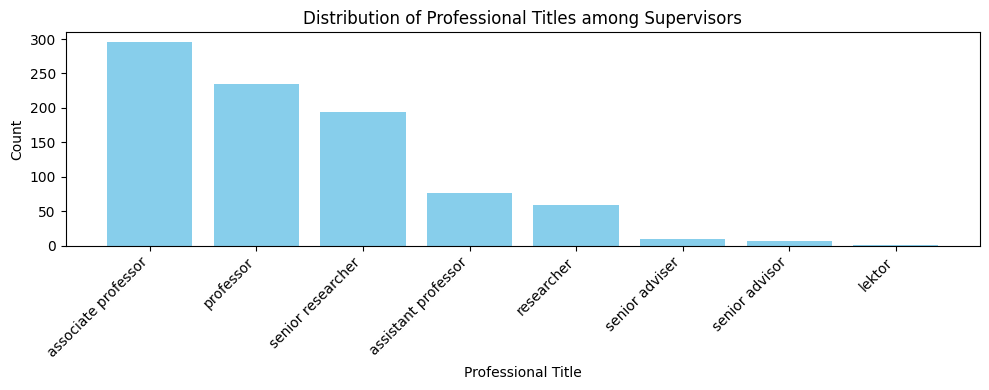

In [28]:
# 2) Distribution of professional titles
print("\nProfessional title distribution:")
# 2.1) Table of distribution of professional titles
title_stats = (
    orbit_data["professional_title"]
    .value_counts(dropna=False)
    .rename_axis("professional_title")
    .reset_index(name="count")
)
title_stats["pct"] = (title_stats["count"] / n_rows * 100).round(2)
display(title_stats)

# 2.2) Bar chart of distribution of professional titles
plt.figure(figsize=(10, 4))
plt.bar(title_stats["professional_title"], title_stats["count"], color="skyblue")
plt.xlabel("Professional Title")
plt.ylabel("Count")
plt.title("Distribution of Professional Titles among Supervisors")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Department distribution:


,dep_match,count,pct
0,DTU Construct,87,9.93
1,DTU Aqua,76,8.68
2,DTU Compute,73,8.33
3,DTU Wind,68,7.76
4,DTU Sustain,64,7.31
5,DTU Food,63,7.19
6,DTU Electro,53,6.05
7,DTU Engineering Technology,53,6.05
8,DTU Bioengineering,47,5.37
9,DTU Health Tech,44,5.02


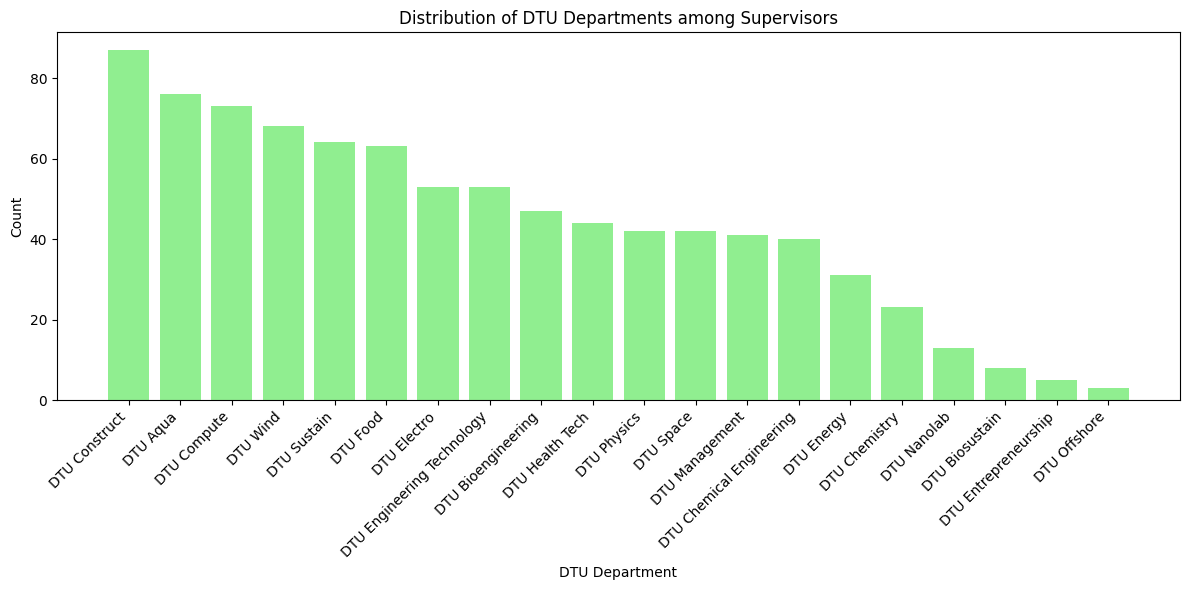

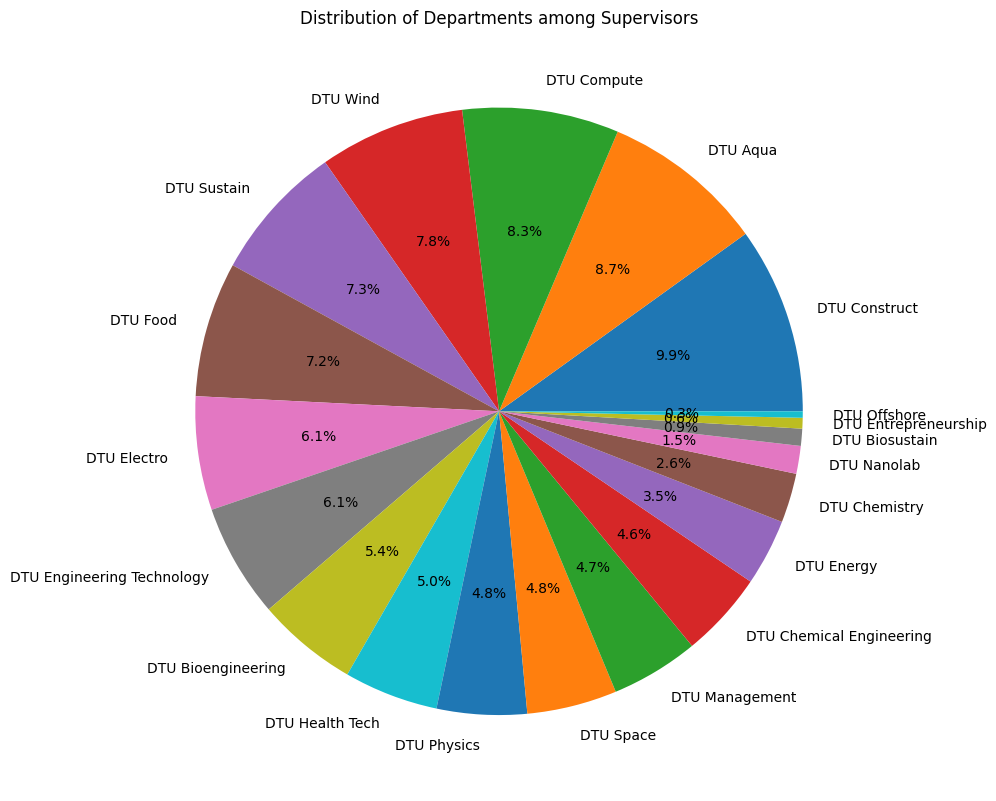

In [35]:
# 3) Distribution of DTU departments
print("\nDepartment distribution:")

# 3.1) Table of distribution of departments
dep_stats = (
    orbit_data["dep_match"]
    .value_counts(dropna=False)
    .rename_axis("dep_match")
    .reset_index(name="count")
)
dep_stats["pct"] = (dep_stats["count"] / n_rows * 100).round(2)

display(dep_stats)

# 3.2) Bar chart of distribution of departments
plt.figure(figsize=(12, 6))
plt.bar(dep_stats["dep_match"], dep_stats["count"], color="lightgreen")
plt.xlabel("DTU Department")
plt.ylabel("Count")
plt.title("Distribution of DTU Departments among Supervisors")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3.3) Pie chart of distribution of departments
plt.figure(figsize=(10, 10))
plt.pie(dep_stats["pct"], labels=dep_stats["dep_match"], autopct="%1.1f%%")
plt.title("Distribution of Departments among Supervisors")
plt.tight_layout()
plt.show()

# EVERYTHING EVERYWHERE ALL AT ONCE

In [36]:
# 4) Title x Department cross table
ct = pd.crosstab(orbit_data["professional_title"], orbit_data["dep_match"])
ct_with_total = ct.copy()
ct_with_total["Total"] = ct_with_total.sum(axis=1)

print("\nCross table (counts): professional_title x dep_match")
display(ct_with_total)

# 5) Normalized views
ct_row_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)   # department mix within each title
ct_col_pct = (ct.div(ct.sum(axis=0), axis=1) * 100).round(1)   # title mix within each department

print("\nRow-normalized cross table (% within each professional_title):")
display(ct_row_pct)

print("\nColumn-normalized cross table (% within each dep_match):")
display(ct_col_pct)

# 6) Most frequent title-department combinations
pair_stats = (
    orbit_data.groupby(["professional_title", "dep_match"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
pair_stats["pct_of_all"] = (pair_stats["count"] / n_rows * 100).round(2)

print("\nTop 20 title-department pairs:")
display(pair_stats.head(20))

# 7) Diversity metrics
# Number of unique titles per department + dominant title share
dep_diversity = (
    orbit_data.groupby("dep_match")["professional_title"]
    .nunique()
    .rename("n_unique_titles")
    .reset_index()
)

dep_top_title = (
    orbit_data.groupby(["dep_match", "professional_title"])
    .size()
    .reset_index(name="count")
    .sort_values(["dep_match", "count"], ascending=[True, False])
    .drop_duplicates("dep_match")
    .rename(columns={"professional_title": "top_title", "count": "top_title_count"})
)

dep_sizes = (
    orbit_data.groupby("dep_match")
    .size()
    .rename("department_total")
    .reset_index()
)

dep_summary = dep_sizes.merge(dep_diversity, on="dep_match").merge(dep_top_title, on="dep_match")
dep_summary["top_title_share_pct"] = (dep_summary["top_title_count"] / dep_summary["department_total"] * 100).round(2)
dep_summary = dep_summary.sort_values("department_total", ascending=False)

print("\nDepartment-level diversity and dominant title:")
display(dep_summary)

# Number of unique departments per title
title_spread = (
    orbit_data.groupby("professional_title")["dep_match"]
    .nunique()
    .rename("n_unique_departments")
    .reset_index()
    .sort_values("n_unique_departments", ascending=False)
)

print("\nTitle spread across departments:")
display(title_spread)


Cross table (counts): professional_title x dep_match


dep_match,DTU Aqua,DTU Bioengineering,DTU Biosustain,DTU Chemical Engineering,DTU Chemistry,DTU Compute,DTU Construct,DTU Electro,DTU Energy,DTU Engineering Technology,...,DTU Food,DTU Health Tech,DTU Management,DTU Nanolab,DTU Offshore,DTU Physics,DTU Space,DTU Sustain,DTU Wind,Total
professional_title,,,,,,,,,,,,,,,,,,,,,
assistant professor,1,5,0,3,2,3,6,5,5,10,...,6,12,3,1,0,1,1,9,3,76
associate professor,4,14,0,8,5,43,42,24,8,41,...,15,13,16,3,0,9,9,24,13,295
lektor,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
professor,24,15,3,14,14,24,17,6,13,2,...,10,7,20,6,0,18,10,17,14,235
researcher,10,1,1,7,1,0,6,5,2,0,...,5,3,0,0,0,4,4,2,8,59
senior adviser,2,0,0,0,0,0,0,0,0,0,...,7,0,0,0,0,0,0,0,0,9
senior advisor,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,4,7
senior researcher,35,12,4,8,1,3,16,12,3,0,...,19,8,2,3,3,10,17,12,26,194



Row-normalized cross table (% within each professional_title):


dep_match,DTU Aqua,DTU Bioengineering,DTU Biosustain,DTU Chemical Engineering,DTU Chemistry,DTU Compute,DTU Construct,DTU Electro,DTU Energy,DTU Engineering Technology,DTU Entrepreneurship,DTU Food,DTU Health Tech,DTU Management,DTU Nanolab,DTU Offshore,DTU Physics,DTU Space,DTU Sustain,DTU Wind
professional_title,,,,,,,,,,,,,,,,,,,,
assistant professor,1.3,6.6,0.0,3.9,2.6,3.9,7.9,6.6,6.6,13.2,0.0,7.9,15.8,3.9,1.3,0.0,1.3,1.3,11.8,3.9
associate professor,1.4,4.7,0.0,2.7,1.7,14.6,14.2,8.1,2.7,13.9,1.4,5.1,4.4,5.4,1.0,0.0,3.1,3.1,8.1,4.4
lektor,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
professor,10.2,6.4,1.3,6.0,6.0,10.2,7.2,2.6,5.5,0.9,0.4,4.3,3.0,8.5,2.6,0.0,7.7,4.3,7.2,6.0
researcher,16.9,1.7,1.7,11.9,1.7,0.0,10.2,8.5,3.4,0.0,0.0,8.5,5.1,0.0,0.0,0.0,6.8,6.8,3.4,13.6
senior adviser,22.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
senior advisor,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.3,0.0,0.0,0.0,14.3,0.0,0.0,0.0,0.0,0.0,14.3,0.0,57.1
senior researcher,18.0,6.2,2.1,4.1,0.5,1.5,8.2,6.2,1.5,0.0,0.0,9.8,4.1,1.0,1.5,1.5,5.2,8.8,6.2,13.4



Column-normalized cross table (% within each dep_match):


...

,professional_title,dep_match,count,pct_of_all
21,associate professor,DTU Compute,43,4.91
22,associate professor,DTU Construct,42,4.79
25,associate professor,DTU Engineering Technology,41,4.68
75,senior researcher,DTU Aqua,35,4.00
92,senior researcher,DTU Wind,26,2.97
41,professor,DTU Compute,24,2.74
36,professor,DTU Aqua,24,2.74
33,associate professor,DTU Sustain,24,2.74
23,associate professor,DTU Electro,24,2.74
49,professor,DTU Management,20,2.28



Department-level diversity and dominant title:


,dep_match,department_total,n_unique_titles,top_title,top_title_count,top_title_share_pct
6,DTU Construct,87,5,associate professor,42,48.28
0,DTU Aqua,76,6,senior researcher,35,46.05
5,DTU Compute,73,4,associate professor,43,58.90
19,DTU Wind,68,6,senior researcher,26,38.24
18,DTU Sustain,64,5,associate professor,24,37.50
11,DTU Food,63,7,senior researcher,19,30.16
7,DTU Electro,53,6,associate professor,24,45.28
9,DTU Engineering Technology,53,3,associate professor,41,77.36
1,DTU Bioengineering,47,5,professor,15,31.91
12,DTU Health Tech,44,6,associate professor,13,29.55



Title spread across departments:


,professional_title,n_unique_departments
3,professor,19
1,associate professor,18
7,senior researcher,18
0,assistant professor,17
4,researcher,14
6,senior advisor,4
5,senior adviser,2
2,lektor,1
